In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-11-17 13:10:20.281336


# Preliminary QC -- Filter transcript count, floor threshold

Workflow: filter only cells with very few counts. Then proceed to remove peyer's patches, run scrublet, filter on area.

In [2]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import sys
import session_info

### Set paths, import data

In [3]:
#base_dir = Path('/home/workspace/projects/drg')

#input_dir = base_dir / "data/h5ad/export_01/01_raw/output_folder"
#output_dir = base_dir / "data/h5ad/export_01/02_pre-filtered"

#os.makedirs(output_dir, exist_ok=True)

base_dir = Path('/home/workspace/projects/drg')
input_dirs = {
    "whole": base_dir / "data/h5ad/export_01/02a_raw/output_folder/whole",
    "nuclear": base_dir / "data/h5ad/export_01/02b_raw/output_folder/nuclear_only",
}
output_dirs = {
    "whole": base_dir / "data/h5ad/export_01/03a_pre-filtered/whole",
    "nuclear": base_dir / "data/h5ad/export_01/03b_pre-filtered/nuclear_only",
}
for d in output_dirs.values():
    d.mkdir(parents=True, exist_ok=True)

Make a dictionary of files in the directory:

In [4]:
whole_files = [
    f for f in os.listdir(input_dirs["whole"])
    if f.endswith(".h5ad") and f.startswith("TMA")
]
nuclear_files = [
    f for f in os.listdir(input_dirs["nuclear"])
    if f.endswith(".h5ad") and f.startswith("TMA")
]

whole_adata_list = [ad.read_h5ad(input_dirs["whole"] / f) for f in whole_files]
nuclear_adata_list = [ad.read_h5ad(input_dirs["nuclear"] / f) for f in nuclear_files]

In [5]:
print(whole_adata_list)
print('-'*40)
print(nuclear_adata_list)

[AnnData object with n_obs × n_vars = 24375 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nuclear_fraction'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'
    layers: 'nuclear', 'raw', AnnData object with n_obs × n_vars = 37315 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassi

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` 

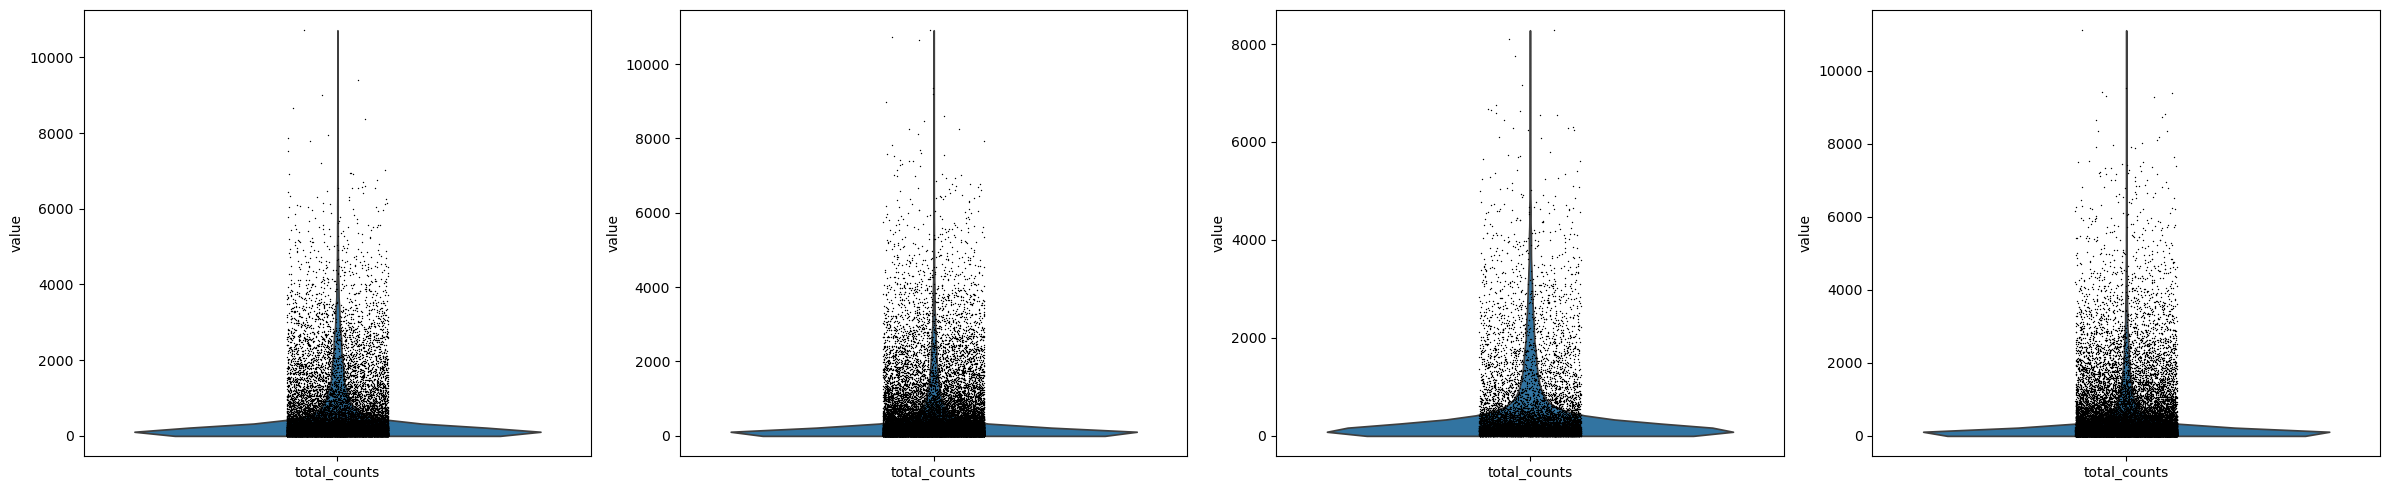

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` 

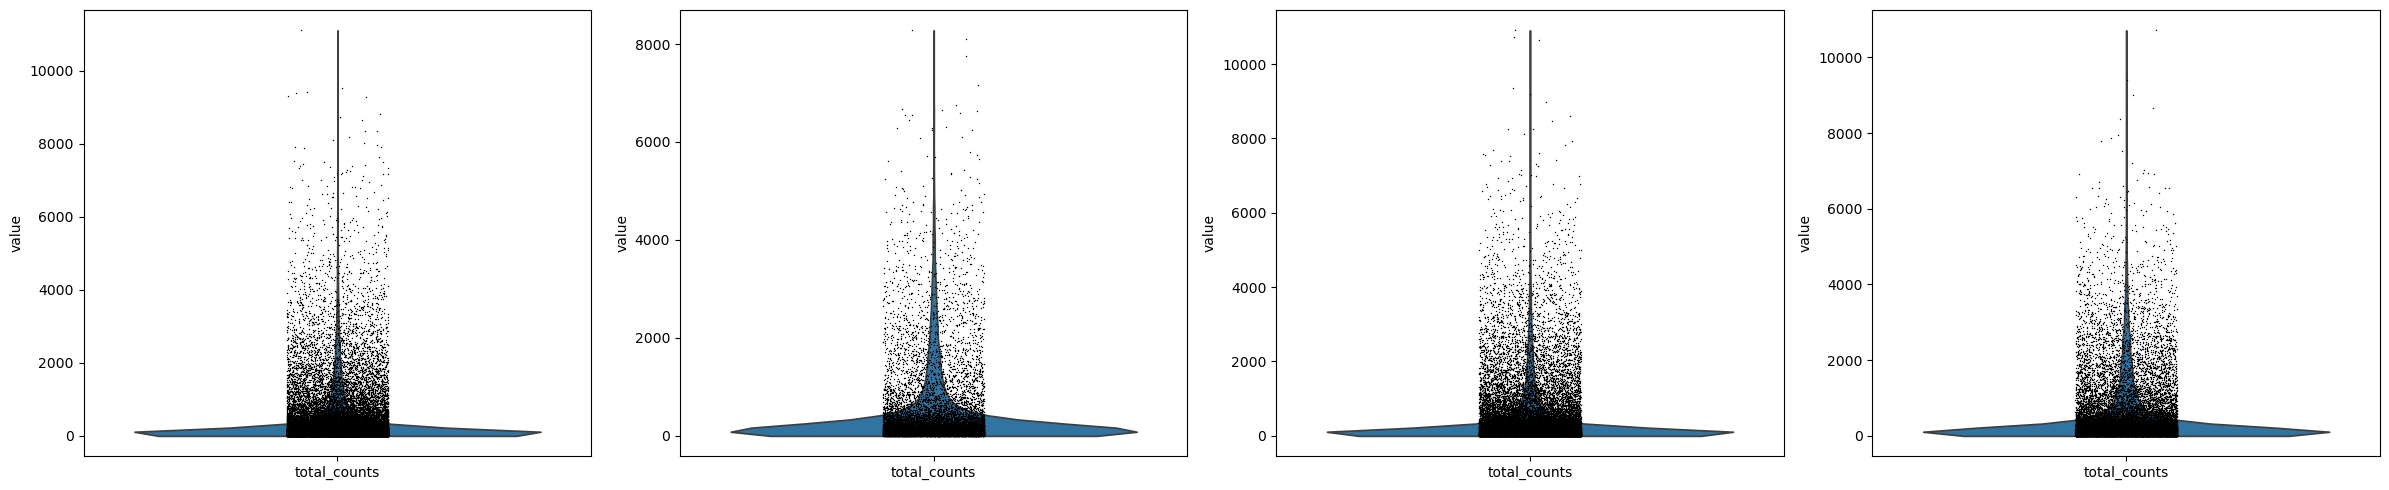

In [6]:
def plot_violin_subplots(adata_list, obs_keys):
    n = len(adata_list)
    fig, axs = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axs = [axs]
    for ax, adata in zip(axs, adata_list):
        sc.pl.violin(adata, obs_keys, show=False, ax=ax)
        ax.set_title(getattr(adata, 'filename', 'Sample'))
    plt.tight_layout()
    plt.show()


plot_violin_subplots(whole_adata_list, ['total_counts'])
plot_violin_subplots(nuclear_adata_list, ['total_counts'])

## Filter

In [7]:
print("\nWhole cell datasets:")
for f, adata in zip(whole_files, whole_adata_list):
    print(f"{f} > {adata.n_obs:,} cells × {adata.n_vars:,} genes")

print("\nNuclear datasets:")
for f, adata in zip(nuclear_files, nuclear_adata_list):
    print(f"{f} > {adata.n_obs:,} cells × {adata.n_vars:,} genes")



Whole cell datasets:
TMA00304.h5ad > 24,375 cells × 480 genes
TMA00306.h5ad > 37,315 cells × 480 genes
TMA00303.h5ad > 12,755 cells × 480 genes
TMA00305.h5ad > 38,753 cells × 480 genes

Nuclear datasets:
TMA00305_nuclear.h5ad > 38,753 cells × 480 genes
TMA00303_nuclear.h5ad > 12,755 cells × 480 genes
TMA00306_nuclear.h5ad > 37,315 cells × 480 genes
TMA00304_nuclear.h5ad > 24,375 cells × 480 genes


Whole 0 before: (24375, 480)
Whole 0 after:  (21501, 480)
Whole 1 before: (37315, 480)
Whole 1 after:  (32284, 480)
Whole 2 before: (12755, 480)
Whole 2 after:  (11408, 480)
Whole 3 before: (38753, 480)
Whole 3 after:  (33118, 480)
Nuclear 0 before: (38753, 480)
Nuclear 0 after:  (33118, 480)
Nuclear 1 before: (12755, 480)
Nuclear 1 after:  (11408, 480)
Nuclear 2 before: (37315, 480)
Nuclear 2 after:  (32284, 480)
Nuclear 3 before: (24375, 480)
Nuclear 3 after:  (21501, 480)


/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` 

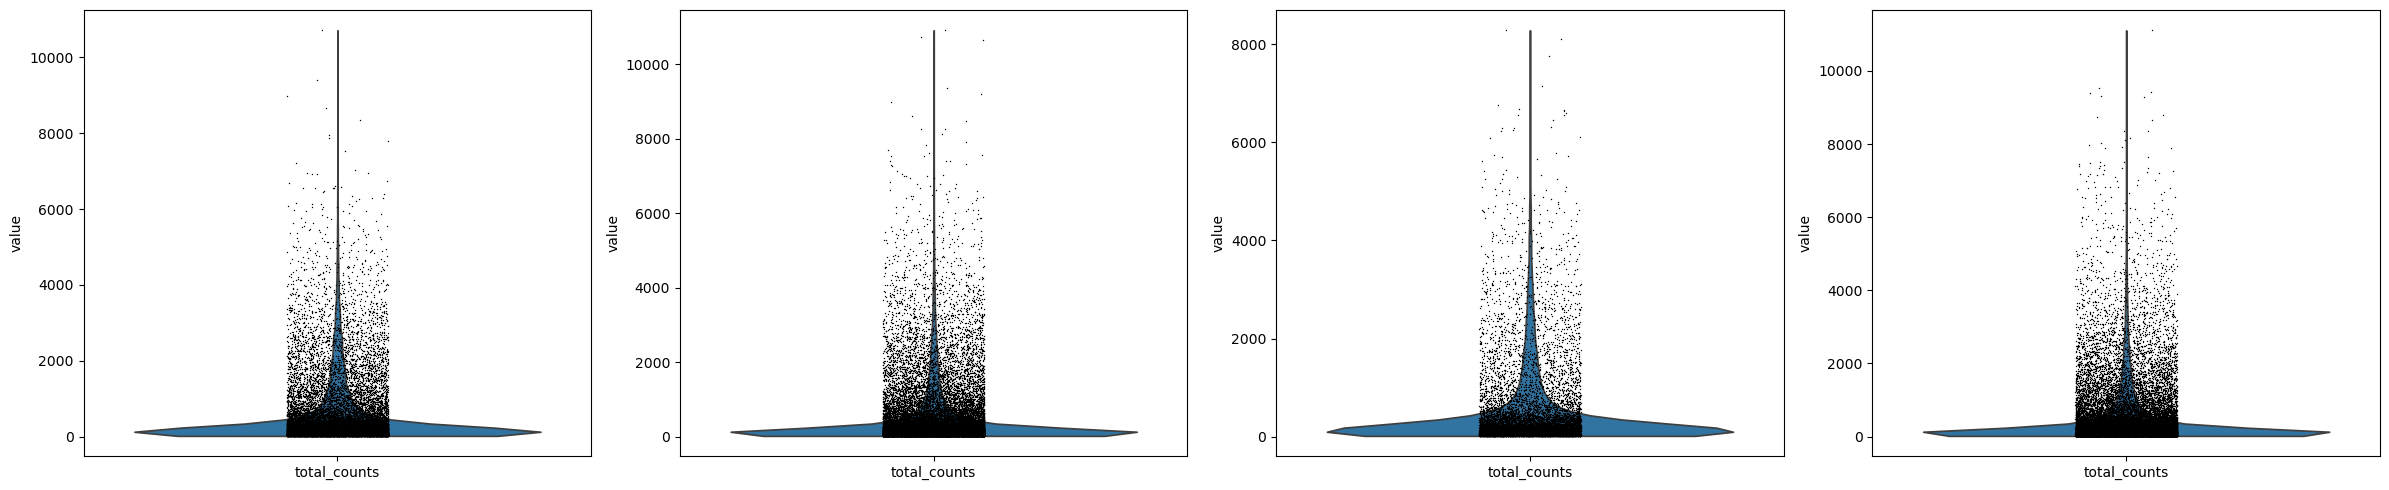

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` 

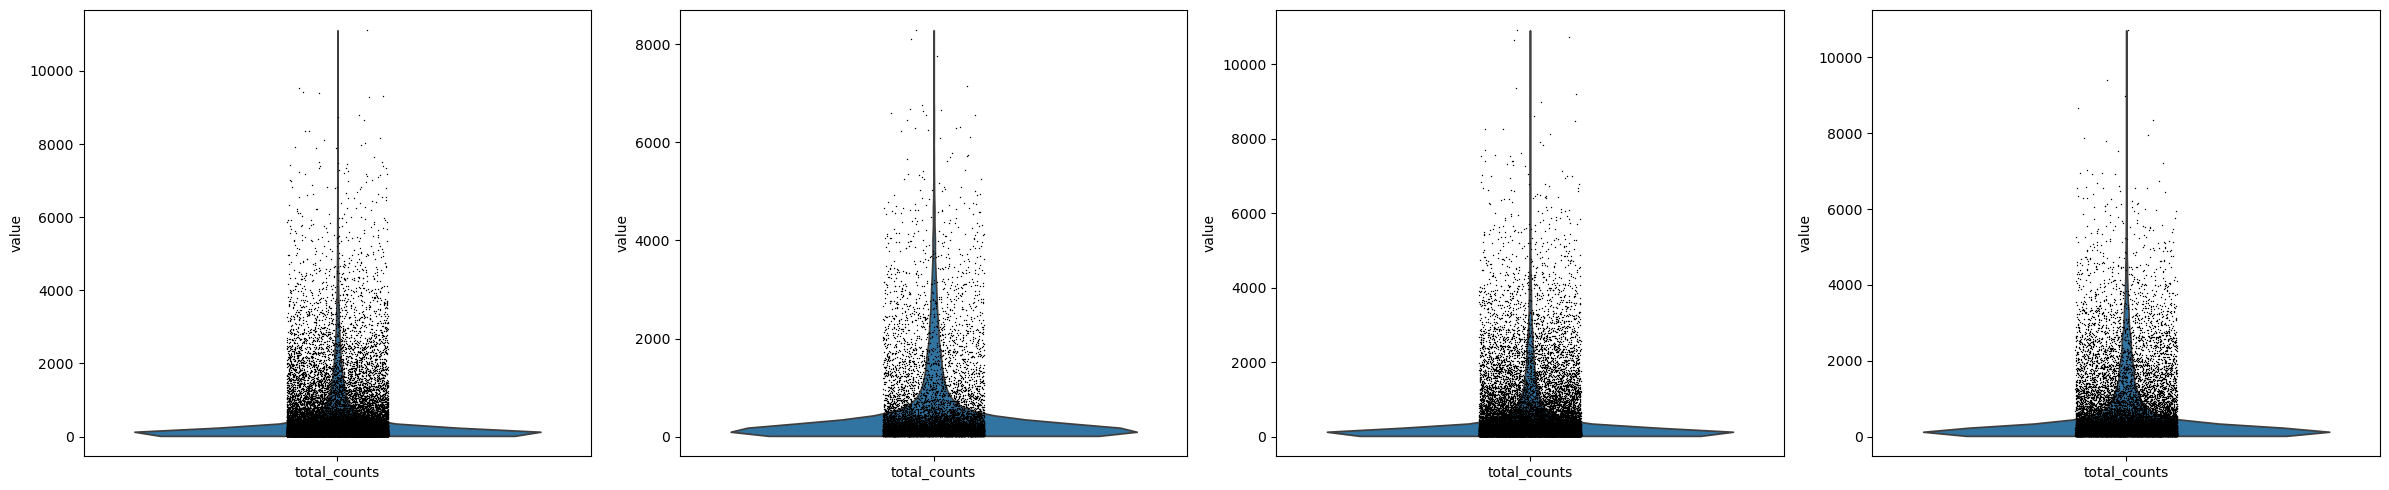

In [8]:
for i, adata in enumerate(whole_adata_list):
    print(f"Whole {i} before: {adata.shape}")
    whole_adata_list[i] = adata[adata.obs['total_counts'] > 20, :].copy()
    print(f"Whole {i} after:  {whole_adata_list[i].shape}")

for i, adata in enumerate(nuclear_adata_list):
    print(f"Nuclear {i} before: {adata.shape}")
    nuclear_adata_list[i] = adata[adata.obs['total_counts'] > 20, :].copy()
    print(f"Nuclear {i} after:  {nuclear_adata_list[i].shape}")

plot_violin_subplots(whole_adata_list, ['total_counts'])
plot_violin_subplots(nuclear_adata_list, ['total_counts'])

In [9]:
print(whole_adata_list)
print('-'*40)
print(nuclear_adata_list)

[AnnData object with n_obs × n_vars = 21501 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nuclear_fraction'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'
    layers: 'nuclear', 'raw', AnnData object with n_obs × n_vars = 32284 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassi

## Export

In [10]:
for i, (adata, fname) in enumerate(zip(whole_adata_list, whole_files)):
    sample_name = adata.obs["output_id"].iloc[0]
    out_file = output_dirs["whole"] / fname
    adata.write(out_file)
    print(f"Saved whole:   {out_file}")

for i, (adata, fname) in enumerate(zip(nuclear_adata_list, nuclear_files)):
    sample_name = adata.obs["output_id"].iloc[0]
    out_file = output_dirs["nuclear"] / fname
    adata.write(out_file)
    print(f"Saved nuclear: {out_file}")

Saved whole:   /home/workspace/projects/drg/data/h5ad/export_01/03a_pre-filtered/whole/TMA00304.h5ad
Saved whole:   /home/workspace/projects/drg/data/h5ad/export_01/03a_pre-filtered/whole/TMA00306.h5ad
Saved whole:   /home/workspace/projects/drg/data/h5ad/export_01/03a_pre-filtered/whole/TMA00303.h5ad
Saved whole:   /home/workspace/projects/drg/data/h5ad/export_01/03a_pre-filtered/whole/TMA00305.h5ad
Saved nuclear: /home/workspace/projects/drg/data/h5ad/export_01/03b_pre-filtered/nuclear_only/TMA00305_nuclear.h5ad
Saved nuclear: /home/workspace/projects/drg/data/h5ad/export_01/03b_pre-filtered/nuclear_only/TMA00303_nuclear.h5ad
Saved nuclear: /home/workspace/projects/drg/data/h5ad/export_01/03b_pre-filtered/nuclear_only/TMA00306_nuclear.h5ad
Saved nuclear: /home/workspace/projects/drg/data/h5ad/export_01/03b_pre-filtered/nuclear_only/TMA00304_nuclear.h5ad


## Session info

In [11]:
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active conda environment: sc-spatial
